# Dataset Pipeline Validation

In this notebook, we:
- Define image and mask transforms
- Implement CocoSegmentationDataset
- Create DataLoader
- Validate batching and tensor shapes

### 0. Set Random Seed

Must be done first — ensures reproducible data splits, model init, and shuffling.

In [16]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### 1. Import Libraries

Import all necessary libraries for data processing, PyTorch dataset creation, and visualization.

In [17]:
import os
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from pycocotools.coco import COCO
from PIL import Image
import sys
sys.path.append(os.path.abspath(".."))
from src.model import UNet

### 2. Load COCO Dataset Annotations

Initialize the COCO API to load and parse the instance annotations for the train2017 dataset.

In [18]:
annotation_path = "../data/annotations/instances_train2017.json"
coco = COCO(annotation_path)

loading annotations into memory...
Done (t=11.74s)
creating index...
index created!


### 3. Define Image and Mask Transforms

- **Image Transform**: Resize to 256×256, convert to tensor, normalize with ImageNet stats.
- **Mask Transform**: Resize to 256×256 with `NEAREST` interpolation (preserves binary 0/1 values), convert to tensor of shape `(1, 256, 256)`.

In [19]:
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(
        (256, 256),
        interpolation=transforms.InterpolationMode.NEAREST  
    ),
    transforms.Lambda(
        lambda x: torch.from_numpy(np.array(x)).float().unsqueeze(0)
    )
])

### 4. Build the Dataset Class
We create a custom PyTorch `Dataset` called `CocoSegmentationDataset`.
This dataset reads images from the local folder, fetches the corresponding annotations via the COCO API, generates a segmentation mask for the specified category (e.g., 'person'), and applies the defined transforms.

In [20]:
class CocoSegmentationDataset(Dataset):
    def __init__(self, coco, image_folder,
                 category_name='person',
                 image_transform=None,
                 mask_transform=None):

        self.coco = coco
        self.image_folder = image_folder
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.cat_ids = self.coco.getCatIds(catNms=[category_name])
        self.img_ids = self.coco.getImgIds(catIds=self.cat_ids)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):
        try:
            img_id = self.img_ids[index]
            img_info = self.coco.loadImgs(img_id)[0]

            # FIX: use self.image_folder instead of hardcoded path
            img_path = os.path.join(self.image_folder, img_info['file_name'])

            image = Image.open(img_path).convert("RGB")
            image = np.array(image)

            # FIX: iscrowd=False excludes noisy crowd annotations
            ann_ids = self.coco.getAnnIds(
                imgIds=img_info['id'],
                catIds=self.cat_ids,
                iscrowd=False
            )
            anns = self.coco.loadAnns(ann_ids)

            mask = np.zeros((img_info['height'], img_info['width']))
            for ann in anns:
                mask += self.coco.annToMask(ann)
            mask = np.clip(mask, 0, 1).astype(np.uint8)

            if self.image_transform:
                image = self.image_transform(image)
            if self.mask_transform:
                mask = self.mask_transform(mask)

            return image, mask

        except (FileNotFoundError, OSError):
            # Skip missing/corrupted files, try next sample
            return self.__getitem__((index + 1) % len(self))


### 5. Create Dataset and DataLoader Instances
Instantiate the dataset using the 'person' category and wrap it in a PyTorch `DataLoader` to batch and shuffle the data during training.

In [21]:
dataset = CocoSegmentationDataset(
    coco,
    "../data/train2017",
    image_transform=image_transform,
    mask_transform=mask_transform
)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
)

### 6. Test the DataLoader
Fetch one batch of data from the dataloader to verify the output shapes. We expect a batch size of 4.

In [22]:
images, masks = next(iter(dataloader))

print("Batch image shape:", images.shape)  # expect [4, 3, 256, 256]
print("Batch mask shape: ", masks.shape)   # expect [4, 1, 256, 256]
print("Unique mask values:", torch.unique(masks))  # expect tensor([0., 1.])

Batch image shape: torch.Size([4, 3, 256, 256])
Batch mask shape:  torch.Size([4, 1, 256, 256])
Unique mask values: tensor([0., 1.])


### 7. Visualize a Sample Batch
Plot an image and its corresponding mask to visually confirm that the pipeline aligns the image and mask correctly. The image is un-normalized before display to avoid matplotlib clipping warnings.

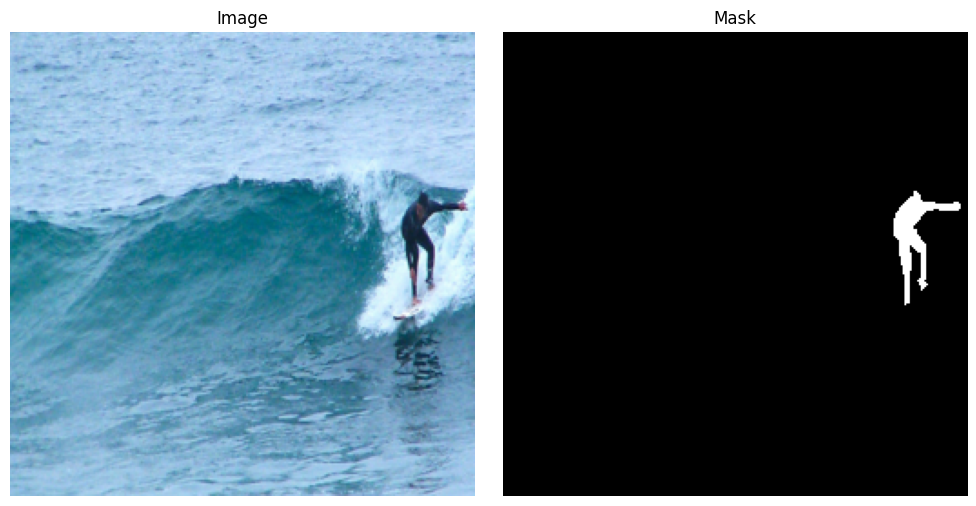

In [23]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Image")
img = images[0].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img = np.clip(std * img + mean, 0, 1)
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(masks[0].squeeze().numpy(), cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

### 8. Load Model and Set Up Training

Initialize UNet, optimizer, and loss.

In [24]:
model = UNet()

# Verify model output shape
x = torch.randn(1, 3, 256, 256)
print("Model output shape:", model(x).shape)  # expect [1, 1, 256, 256]

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

Model output shape: torch.Size([1, 1, 256, 256])


### 9. IoU Helper Function

IoU is the primary metric required by the project rubric.
Always track it alongside loss — loss alone doesn't reflect segmentation quality.

In [25]:
def compute_iou(pred_logits, target, threshold=0.3):
    """
    Computes IoU with a lower threshold to handle early training
    where predictions are not yet confident.
    """
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    
    # If model predicts all zeros, fall back to soft IoU
    if pred.sum() == 0:
        pred_soft = torch.sigmoid(pred_logits)
        intersection = (pred_soft * target).sum()
        union = pred_soft.sum() + target.sum() - intersection
        return (intersection / (union + 1e-6)).item()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection / (union + 1e-6)).item()

### 10. Train/Val Split

Split 300 samples into 240 train / 60 val.
Always hold out a validation set — without it you cannot detect overfitting.

In [26]:
small_dataset = Subset(dataset, range(300))

train_ds, val_ds = random_split(
    small_dataset,
    [240, 60],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 60 | Val batches: 15


### 11. Training Loop

Trains for 5 epochs and prints loss + IoU for both train and val.

In [28]:
num_epochs = 3

for epoch in range(num_epochs):

    # --- Training ---
    model.train()
    train_loss, train_iou = 0.0, 0.0

    for images, masks in train_loader:
        optimizer.zero_grad()          
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou  += compute_iou(outputs, masks)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou  = train_iou  / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss, val_iou = 0.0, 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()
            val_iou  += compute_iou(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou  = val_iou  / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} "
    
          f"| Train Loss: {avg_train_loss:.4f}  Train IoU: {avg_train_iou:.4f} "
          f"| Val Loss: {avg_val_loss:.4f}  Val IoU: {avg_val_iou:.4f}")


Epoch 1/3 | Train Loss: 0.4820  Train IoU: 0.1027 | Val Loss: 0.4272  Val IoU: 0.0342
Epoch 2/3 | Train Loss: 0.4196  Train IoU: 0.1439 | Val Loss: 0.4197  Val IoU: 0.2566
Epoch 3/3 | Train Loss: 0.4035  Train IoU: 0.1915 | Val Loss: 0.4105  Val IoU: 0.2762


## 11. Prediction Visualization

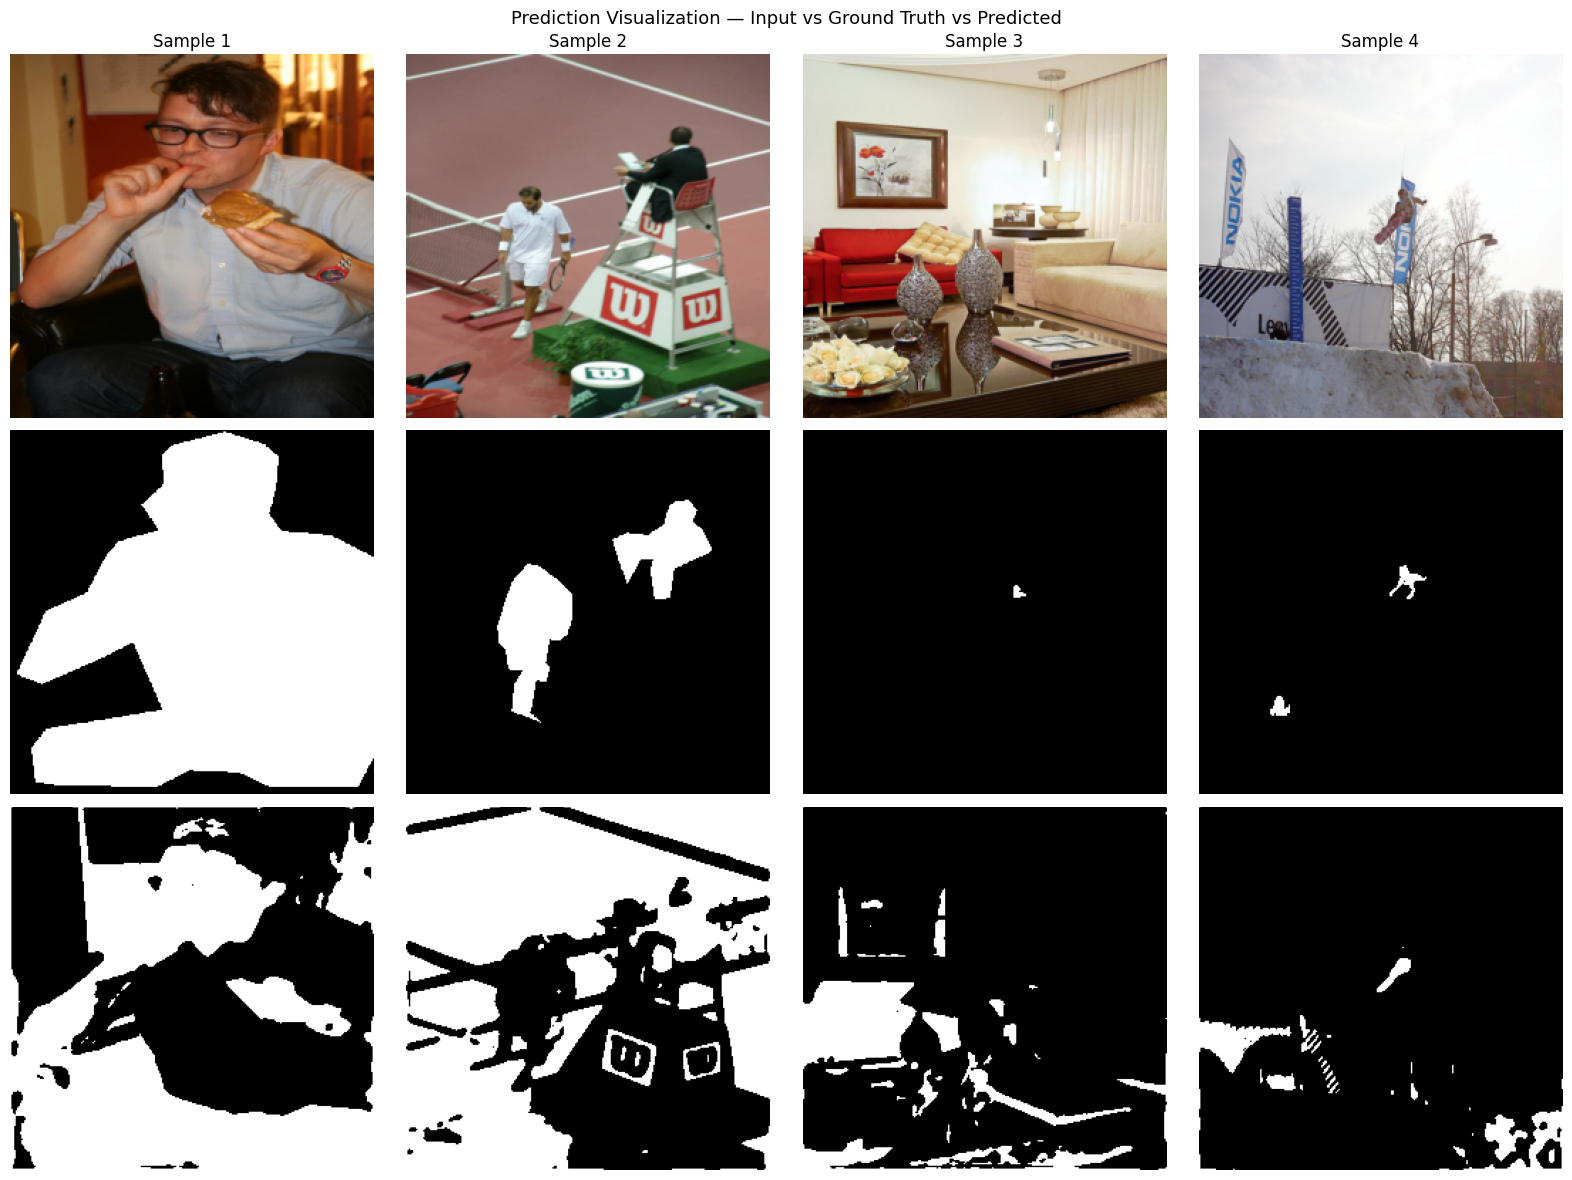

Per-sample IoU on this batch:
  Sample 1: IoU = 0.3823
  Sample 2: IoU = 0.0349
  Sample 3: IoU = 0.0000
  Sample 4: IoU = 0.0391


In [29]:
model.eval()
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Grab one val batch
val_images, val_masks = next(iter(val_loader))

with torch.no_grad():
    val_outputs = model(val_images)
    pred_masks  = (torch.sigmoid(val_outputs) > 0.3).float()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
row_labels = ['Input Image', 'Ground Truth', 'Predicted Mask']

for i in range(4):
    # Row 0 — original image
    img = val_images[i].permute(1, 2, 0).numpy()
    img = np.clip(std * img + mean, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Sample {i+1}")
    axes[0, i].axis('off')

    # Row 1 — ground truth mask
    axes[1, i].imshow(val_masks[i].squeeze().numpy(), cmap='gray')
    axes[1, i].axis('off')

    # Row 2 — predicted mask
    axes[2, i].imshow(pred_masks[i].squeeze().numpy(), cmap='gray')
    axes[2, i].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=10)

plt.suptitle('Prediction Visualization — Input vs Ground Truth vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()

# Per-sample IoU
print("Per-sample IoU on this batch:")
for i in range(4):
    iou = compute_iou(val_outputs[i:i+1], val_masks[i:i+1])
    print(f"  Sample {i+1}: IoU = {iou:.4f}")

## 13. LR Experiment

=== lr = 1e-3 ===
  lr=0.001 | Epoch 1/3 Val Loss: 0.4243  Val IoU: 0.0538
  lr=0.001 | Epoch 2/3 Val Loss: 0.4094  Val IoU: 0.2699
  lr=0.001 | Epoch 3/3 Val Loss: 0.4118  Val IoU: 0.2926

=== lr = 1e-4 ===
  lr=0.0001 | Epoch 1/3 Val Loss: 0.4637  Val IoU: 0.1276
  lr=0.0001 | Epoch 2/3 Val Loss: 0.4451  Val IoU: 0.1233
  lr=0.0001 | Epoch 3/3 Val Loss: 0.4243  Val IoU: 0.1396


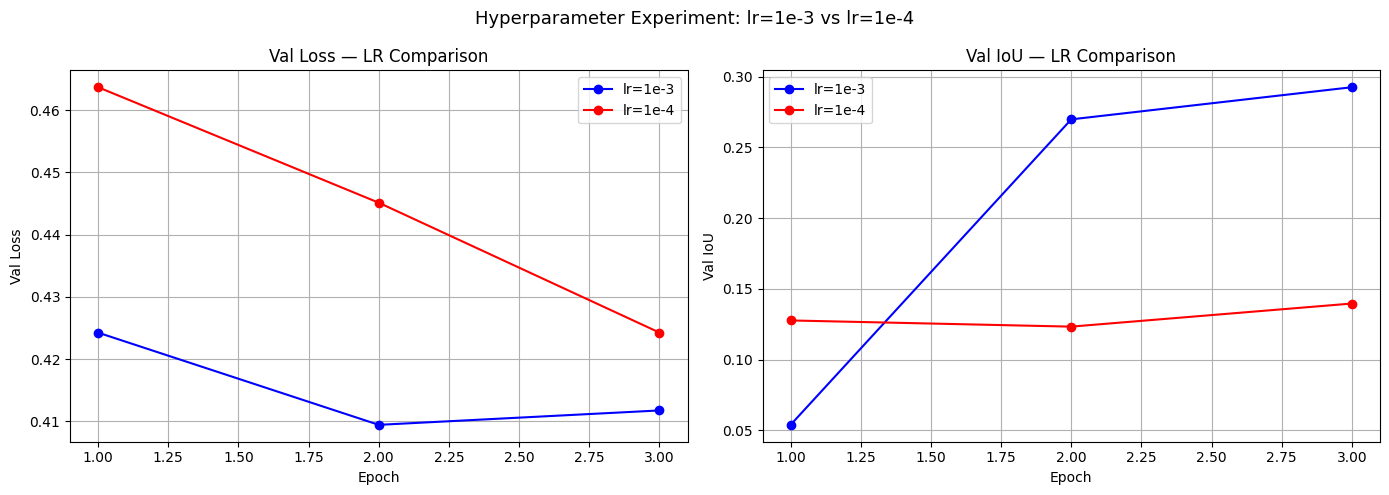


Conclusion: lr=1e-3 achieved lower validation loss — use this for full training.


In [30]:
def run_experiment(lr, train_loader, val_loader, num_epochs=3):
    torch.manual_seed(SEED)
    exp_model     = UNet()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr)
    exp_criterion = nn.BCEWithLogitsLoss()

    val_losses, val_ious = [], []

    for epoch in range(num_epochs):
        exp_model.train()
        for imgs, msks in train_loader:
            exp_optimizer.zero_grad()
            out  = exp_model(imgs)
            loss = exp_criterion(out, msks)
            loss.backward()
            exp_optimizer.step()

        exp_model.eval()
        vl, vi = 0.0, 0.0
        with torch.no_grad():
            for imgs, msks in val_loader:
                out  = exp_model(imgs)
                vl  += exp_criterion(out, msks).item()
                vi  += compute_iou(out, msks)
        val_losses.append(vl / len(val_loader))
        val_ious.append(vi / len(val_loader))
        print(f"  lr={lr} | Epoch {epoch+1}/{num_epochs} "
              f"Val Loss: {val_losses[-1]:.4f}  Val IoU: {val_ious[-1]:.4f}")

    return val_losses, val_ious


print("=== lr = 1e-3 ===")
loss_1e3, iou_1e3 = run_experiment(1e-3, train_loader, val_loader)

print("\n=== lr = 1e-4 ===")
loss_1e4, iou_1e4 = run_experiment(1e-4, train_loader, val_loader)

# Plot comparison
epochs = range(1, 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, loss_1e3, 'b-o', label='lr=1e-3')
axes[0].plot(epochs, loss_1e4, 'r-o', label='lr=1e-4')
axes[0].set_title('Val Loss — LR Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, iou_1e3, 'b-o', label='lr=1e-3')
axes[1].plot(epochs, iou_1e4, 'r-o', label='lr=1e-4')
axes[1].set_title('Val IoU — LR Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val IoU')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Hyperparameter Experiment: lr=1e-3 vs lr=1e-4', fontsize=13)
plt.tight_layout()
plt.show()

best_lr = '1e-3' if min(loss_1e3) < min(loss_1e4) else '1e-4'
print(f"\nConclusion: lr={best_lr} achieved lower validation loss — use this for full training.")